# NEAT — NeuroEvolution of Augmenting Topologies

Implementation of the NEAT algorithm (Stanley & Miikkulainen, 2002) evaluated on three Gymnasium
benchmarks (CartPole, LunarLander, BipedalWalker), plus experiments on speciation, mutation rates and
network complexity.

Paper: https://nn.cs.utexas.edu/downloads/papers/stanley.ec02.pdf

Structure: implementation -> visualisation helpers -> 3 benchmarks -> 3 analyses -> genetic distance.
The notebook is written to run top-to-bottom (Restart & Run All).

In [1]:
from __future__ import annotations

import copy
import itertools
from dataclasses import dataclass, replace
from enum import Enum
from typing import Callable
from collections import Counter, defaultdict

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym

## Genome configuration and activation functions

The original paper uses a steepened sigmoid `y = 1/(1+e^{-4.9x})` with range [0, 1]. That cannot express
a negative torque, so BipedalWalker (continuous actions in [-1, 1]) requires `tanh`. For the two discrete
environments only the `argmax` over the outputs matters, so the choice makes no difference there. All
three benchmarks therefore use `tanh`; `neat_sigmoid` stays available as a configurable alternative.

In [2]:
def neat_tanh(W, x):
    return np.tanh(W @ x)


def neat_sigmoid(W, x):
    # NEAT steepened sigmoid; the clip keeps exp() from overflowing for large weights
    return 1 / (1 + np.exp(np.clip(-4.9 * (W @ x), -500, 500)))


@dataclass
class GenomeConfig:
    cross_p_inherit_weaker: float = 0.5
    cross_p_stay_disabled: float = 0.75
    mut_p_add_node: float = 0.05        # Analysis 2 measures this: 0.05 scores best, 0.0 clearly worst
    mut_p_add_link: float = 0.1
    mut_p_replace: float = 0.1          # 1 - p_replace = p_perturbate
    mut_pertubation_range: float = 2.0
    mut_max_weight: float = 8.0
    mut_min_weight: float = -8.0
    mut_clip_weights: bool = True
    activation_fun: Callable = neat_tanh

## Genome (`Individual`)

A genome *is* a `networkx.DiGraph`: nodes carry a `type` (INPUT/BIAS/OUTPUT/HIDDEN), edges carry
`innov`, `weight` and `enabled`. Aligning two genomes by innovation number is therefore a dictionary
join, and the acyclicity check is `nx.has_path`.

The **bias node** is an input permanently clamped to 1.0. Without it every activation is forced through
the origin (`tanh(0) = 0`), no neuron can shift its own threshold, and the representable policies are
needlessly restricted.

For the forward pass the graph is compiled once into a dense weight matrix `W`; because the graph is a
DAG of depth `d`, iterating `state <- act(W @ state)` exactly `d` times reproduces the true feed-forward
output.

In [3]:
class NodeType(Enum):
    INPUT = 0
    OUTPUT = 1
    HIDDEN = 2
    BIAS = 3


class Individual:
    """One genome / network / solution."""

    def __init__(self, config: GenomeConfig = None):
        self.config = config if config else GenomeConfig()
        self.network = nx.DiGraph()
        self.fitness = 0.0

    def add_node_gene(self, node_id: int, node_type: NodeType):
        self.network.add_node(node_id, type=node_type)

    def add_connection_gene(self, in_node: int, out_node: int, innov: int, weight: float, enabled: bool):
        self.network.add_edge(in_node, out_node, innov=innov, weight=weight, enabled=enabled)

    def n_hidden(self) -> int:
        return sum(1 for _, a in self.network.nodes(data=True) if a['type'] == NodeType.HIDDEN)

    def n_enabled_edges(self) -> int:
        return sum(1 for _, _, a in self.network.edges(data=True) if a['enabled'])

    def clone(self) -> Individual:
        child = Individual(self.config)
        child.network = self.network.copy()
        child.fitness = self.fitness
        child.compile_network()
        return child

    def _get_innov_dict(self):
        """O(1) innovation lookups for crossover / distance."""
        return {attr['innov']: (u, v, attr) for u, v, attr in self.network.edges(data=True)}

    def distance(self, other: Individual, c1=1.0, c2=0.4) -> float:
        """Compatibility distance; excess and disjoint genes are merged into one term."""
        genes_self, genes_other = self._get_innov_dict(), other._get_innov_dict()
        innov_self, innov_other = set(genes_self), set(genes_other)

        matching = innov_self & innov_other
        non_homologous = len(innov_self ^ innov_other)

        if matching:
            w1 = np.array([genes_self[k][2]['weight'] for k in matching])
            w2 = np.array([genes_other[k][2]['weight'] for k in matching])
            weight_diff = float(np.mean(np.abs(w1 - w2)))
        else:
            weight_diff = 0.0

        N = max(len(innov_self), len(innov_other), 1)
        return (c1 * non_homologous / N) + (c2 * weight_diff)

    def crossover(self, other: Individual) -> Individual:
        """Innovation-number aligned crossover."""
        child = Individual(self.config)
        fitter, weaker = (self, other) if self.fitness >= other.fitness else (other, self)

        genes_fitter, genes_weaker = fitter._get_innov_dict(), weaker._get_innov_dict()
        child.network.add_nodes_from(fitter.network.nodes(data=True))

        # iterating only over the fitter parent's genes IS the rule
        # "excess and disjoint genes are inherited from the more fit parent"
        for innov_num, (u, v, attr) in genes_fitter.items():
            child_attr = copy.deepcopy(attr)
            if innov_num in genes_weaker:
                weaker_attr = genes_weaker[innov_num][2]
                if np.random.random() < self.config.cross_p_inherit_weaker:
                    child_attr['weight'] = weaker_attr['weight']
                if not attr['enabled'] or not weaker_attr['enabled']:
                    child_attr['enabled'] = np.random.random() > self.config.cross_p_stay_disabled
            child.network.add_edge(u, v, **child_attr)
        return child

    def mutate_weights(self):
        edges = list(self.network.edges(data=True))
        n = len(edges)
        replacements = np.random.uniform(self.config.mut_min_weight, self.config.mut_max_weight, n)
        perturbations = np.random.uniform(-self.config.mut_pertubation_range,
                                          self.config.mut_pertubation_range, n)
        action_probs = np.random.rand(n)

        for i, (_, _, attr) in enumerate(edges):
            if action_probs[i] < self.config.mut_p_replace:
                attr['weight'] = replacements[i]
            else:
                attr['weight'] += perturbations[i]
                if self.config.mut_clip_weights:
                    attr['weight'] = float(np.clip(attr['weight'],
                                                   self.config.mut_min_weight,
                                                   self.config.mut_max_weight))

    def mutate_genes(self, get_link_innovation: Callable, get_node_innovation: Callable):
        if np.random.random() < self.config.mut_p_add_link:
            nodes = list(self.network.nodes(data=True))
            in_node, in_attr = nodes[np.random.choice(len(nodes))]
            out_node, out_attr = nodes[np.random.choice(len(nodes))]

            # nothing may feed into an input or into the bias, and an output may not be a source
            valid_type = (in_attr['type'] != NodeType.OUTPUT
                          and out_attr['type'] not in (NodeType.INPUT, NodeType.BIAS))
            is_new = not self.network.has_edge(in_node, out_node)
            not_self_loop = in_node != out_node
            # adding in->out closes a cycle iff a path out->in already exists
            no_cycle = not nx.has_path(self.network, out_node, in_node)

            if valid_type and not_self_loop and is_new and no_cycle:
                self.add_connection_gene(
                    in_node, out_node,
                    innov=get_link_innovation(in_node, out_node),
                    weight=float(np.random.uniform(self.config.mut_min_weight,
                                                   self.config.mut_max_weight)),
                    enabled=True)

        if np.random.random() < self.config.mut_p_add_node:
            # split N1 -> N2 into N1 -> Nnew -> N2
            enabled_edges = [(u, v, a) for u, v, a in self.network.edges(data=True) if a['enabled']]
            if not enabled_edges:
                return
            n_1, n_2, attr = enabled_edges[np.random.choice(len(enabled_edges))]
            attr['enabled'] = False

            new_node_id = get_node_innovation(attr['innov'])
            self.add_node_gene(new_node_id, NodeType.HIDDEN)
            # weight 1.0 then the original weight -> the new node is almost a no-op at birth,
            # so it does not wreck the genome's fitness immediately
            self.add_connection_gene(n_1, new_node_id,
                                     innov=get_link_innovation(n_1, new_node_id),
                                     weight=1.0, enabled=True)
            self.add_connection_gene(new_node_id, n_2,
                                     innov=get_link_innovation(new_node_id, n_2),
                                     weight=attr['weight'], enabled=True)

    def compile_network(self):
        """Compile the graph into a dense weight matrix for the forward pass."""
        self._node_idx_map = {key: i for i, key in enumerate(self.network.nodes())}
        n_nodes = len(self._node_idx_map)
        self._W = np.zeros((n_nodes, n_nodes))

        self._input_indices = [self._node_idx_map[n] for n, a in self.network.nodes(data=True)
                               if a['type'] == NodeType.INPUT]
        self._bias_indices = [self._node_idx_map[n] for n, a in self.network.nodes(data=True)
                              if a['type'] == NodeType.BIAS]
        self._output_indices = [self._node_idx_map[n] for n, a in self.network.nodes(data=True)
                                if a['type'] == NodeType.OUTPUT]

        for u, v, attr in self.network.edges(data=True):
            if attr['enabled']:
                self._W[self._node_idx_map[v]][self._node_idx_map[u]] = attr['weight']

        self._network_depth = nx.dag_longest_path_length(self.network, weight=None) + 1

    def forward_pass(self, inputs: np.ndarray) -> np.ndarray:
        if len(inputs) != len(self._input_indices):
            raise ValueError("Number of input nodes doesn't match")

        state = np.zeros(len(self._node_idx_map))
        state[self._input_indices] = inputs
        state[self._bias_indices] = 1.0

        for _ in range(self._network_depth):
            state = self.config.activation_fun(self._W, state)
            # inputs and bias are sources: re-clamp them after every propagation step
            state[self._input_indices] = inputs
            state[self._bias_indices] = 1.0
        return state[self._output_indices]

## Population configuration

In [4]:
@dataclass
class PopulationConfig:
    dropoff_age: int = 15               # a species that stops improving for this long is penalised
    p_selection: float = 0.2            # top 20 % of a species become parents
    p_mutation_without_cross: float = 0.3
    p_interspecies_mate: float = 0.001
    n_min_elite_survival: int = 3       # species needs >= 3 survivors before its champion is copied
    use_random_representatives: bool = True

## Population: speciation and the evolution loop

Two details worth flagging:

**Fitness sharing** — each individual's fitness is divided by the size of its species, so a species
cannot win merely by being large. Offspring are then allocated proportionally to each species' shared
fitness.

**Negative fitness** — LunarLander and BipedalWalker return *negative* rewards for the first several
generations. Proportional allocation on negative sums is meaningless, so the fitness is shifted so that
its minimum is >= 0 before sharing. Clamping negatives to a constant instead would collapse every
negative fitness onto the same value and remove species-level selection pressure entirely for exactly
as long as rewards stay negative.

In [5]:
def cluster_species(individuals: list, previous_representatives: dict,
                    compatibility_threshold: float = 3.0) -> list:
    """Greedy sequential clustering against the previous generation's representatives."""
    representatives = previous_representatives.copy()
    clusters = []
    next_cluster_id = max(representatives.keys()) + 1 if representatives else 0

    for ind in individuals:
        assigned = None
        for cluster_id, rep in representatives.items():
            if ind.distance(rep) < compatibility_threshold:
                assigned = cluster_id
                break
        if assigned is None:                       # no species fits -> found a new one
            assigned = next_cluster_id
            representatives[next_cluster_id] = ind
            next_cluster_id += 1
        clusters.append(assigned)
    return clusters


def no_speciation(individuals: list, previous_representatives: dict,
                  compatibility_threshold: float = 3.0) -> list:
    """Speciation switched off: the whole population is one single species (for Analysis 1)."""
    return [0] * len(individuals)


class Population:
    """NEAT speciation + evolution loop (evaluate -> speciate -> select -> reproduce -> mutate)."""

    def __init__(self, size: int, compatibility_threshold: float, cluster_species_func: Callable,
                 config: PopulationConfig = None):
        self.config = config if config else PopulationConfig()
        self.size = size
        self.individuals = []
        self.cluster_species_func = cluster_species_func
        self.population_counter = {'innov': 0, 'node': 0}
        self.current_generation_innovations = {}
        self.species_history = defaultdict(lambda: {'max_fitness': -float('inf'), 'stagnant_gens': 0})
        self.previous_representatives = {}
        self.compatibility_threshold = compatibility_threshold

    # --- innovation bookkeeping: same structural mutation in one generation -> same number ---
    def _get_link_innovation(self, in_node: int, out_node: int) -> int:
        key = ('link', in_node, out_node)
        if key not in self.current_generation_innovations:
            self.population_counter['innov'] += 1
            self.current_generation_innovations[key] = self.population_counter['innov']
        return self.current_generation_innovations[key]

    def _get_node_innovation(self, link_to_split: int) -> int:
        key = ('node', link_to_split)
        if key not in self.current_generation_innovations:
            self.population_counter['node'] += 1
            self.current_generation_innovations[key] = self.population_counter['node']
        return self.current_generation_innovations[key]

    def reset_generation_innovations(self):
        self.current_generation_innovations.clear()

    # --- fitness evaluation: the whole population in parallel, one env per individual ---
    def evaluate_fitness(self, vector_env, action_mapper=None, max_steps=1000, n_runs=3, seed_base=None):
        if vector_env.num_envs != self.size:
            raise ValueError(f"VectorEnv must have exactly {self.size} environments.")

        total_scores = np.zeros(self.size, dtype=float)

        for run in range(n_runs):
            # every individual of a generation faces the SAME episodes -> fair comparison,
            # and the episodes change from generation to generation -> no overfitting to one start
            if seed_base is None:
                obs, _ = vector_env.reset()
            else:
                obs, _ = vector_env.reset(seed=[int(seed_base + run)] * self.size)

            finished = np.zeros(self.size, dtype=bool)
            run_scores = np.zeros(self.size, dtype=float)

            for _ in range(max_steps):
                if finished.all():
                    break
                actions = []
                for i, ind in enumerate(self.individuals):
                    if not finished[i]:
                        raw = ind.forward_pass(obs[i])
                        actions.append(action_mapper(raw) if action_mapper else raw)
                    else:
                        actions.append(vector_env.single_action_space.sample())   # dummy, masked out

                obs, rewards, terminated, truncated, _ = vector_env.step(np.array(actions))
                run_scores += rewards * (~finished)
                finished |= (terminated | truncated)

            total_scores += run_scores

        for ind, fit in zip(self.individuals, total_scores / n_runs):
            ind.fitness = float(fit)

    # --- one generation of selection / reproduction / mutation ---
    def select_reproduce_mutate(self):
        report = {}
        clusters = self.cluster_species_func(self.individuals, self.previous_representatives,
                                             self.compatibility_threshold)
        n_per_cluster = Counter(clusters)

        # shift to >= 0: proportional allocation is meaningless on negative sums
        raw = np.array([ind.fitness for ind in self.individuals], dtype=float)
        shifted = raw - raw.min() + 1e-6
        shared = shifted / np.array([n_per_cluster[c] for c in clusters])

        report['species'] = {}
        fitness_per_cluster = {}
        global_max = raw.max()
        for cluster in set(clusters):
            members = [ind for ind, c in zip(self.individuals, clusters) if c == cluster]
            max_fit = max(ind.fitness for ind in members)
            report['species'][cluster] = [ind.fitness for ind in members]

            hist = self.species_history[cluster]
            if max_fit > hist['max_fitness']:
                hist['max_fitness'] = max_fit
                hist['stagnant_gens'] = 0
            else:
                hist['stagnant_gens'] += 1

            is_stagnant = hist['stagnant_gens'] >= self.config.dropoff_age
            is_best_species = (max_fit == global_max)      # the champion's species is never culled

            if is_stagnant and not is_best_species:
                fitness_per_cluster[cluster] = 1e-6
            else:
                fitness_per_cluster[cluster] = float(np.sum(shared[np.array(clusters) == cluster]))

        report['sharedfitness_per_cluster'] = fitness_per_cluster

        total = sum(fitness_per_cluster.values())
        allocation = {c: int((f / total) * self.size) for c, f in fitness_per_cluster.items()}
        missing = self.size - sum(allocation.values())
        if missing > 0:
            allocation[max(fitness_per_cluster, key=fitness_per_cluster.get)] += missing
        report['allocations'] = allocation

        # survivors per species
        survivor_map, all_survivors = {}, []
        for cluster in set(clusters):
            members = sorted([ind for ind, c in zip(self.individuals, clusters) if c == cluster],
                             key=lambda i: i.fitness, reverse=True)
            n_surv = max(1, int(len(members) * self.config.p_selection))
            survivor_map[cluster] = members[:n_surv]
            all_survivors.extend(members[:n_surv])

        next_generation = []
        for cluster, n_offspring in allocation.items():
            if n_offspring == 0:
                continue
            survivors = survivor_map[cluster]
            count = 0

            if len(survivors) >= self.config.n_min_elite_survival:
                next_generation.append(survivors[0].clone())     # elitism: champion unchanged
                count += 1

            while count < n_offspring:
                if np.random.random() < self.config.p_mutation_without_cross or len(survivors) < 2:
                    child = np.random.choice(survivors).clone()
                else:
                    i, j = np.random.choice(len(survivors), 2, replace=False)
                    parent1, parent2 = survivors[i], survivors[j]
                    if np.random.random() < self.config.p_interspecies_mate:
                        parent2 = np.random.choice(all_survivors)
                    child = parent1.crossover(parent2)

                child.mutate_weights()
                child.mutate_genes(self._get_link_innovation, self._get_node_innovation)
                child.compile_network()
                next_generation.append(child)
                count += 1

        # representatives for next generation's clustering
        self.previous_representatives.clear()
        for cluster in set(clusters):
            survivors = survivor_map.get(cluster, [])
            if not survivors:
                continue
            self.previous_representatives[cluster] = (np.random.choice(survivors)
                                                      if self.config.use_random_representatives
                                                      else survivors[0])

        self.individuals = next_generation
        self.reset_generation_innovations()
        return report

## Building the initial population

Every genome starts *minimal*: all inputs **and the bias** fully connected to the outputs, **no hidden
nodes**. Structure has to earn its place through mutation, which is exactly NEAT's complexification
principle.

In [6]:
def create_population(size: int, n_inputs: int, n_outputs: int, compatibility_threshold: float,
                      cluster_func: Callable, genome_config: GenomeConfig = None,
                      pop_config: PopulationConfig = None) -> Population:
    pop = Population(size=size, compatibility_threshold=compatibility_threshold,
                     cluster_species_func=cluster_func, config=pop_config)

    bias_id = n_inputs                       # one bias node, clamped to 1.0, sits behind the inputs
    pop.population_counter['node'] = n_inputs + 1 + n_outputs - 1

    for _ in range(size):
        ind = Individual(genome_config)
        for i in range(n_inputs):
            ind.add_node_gene(node_id=i, node_type=NodeType.INPUT)
        ind.add_node_gene(node_id=bias_id, node_type=NodeType.BIAS)
        for j in range(n_outputs):
            ind.add_node_gene(node_id=bias_id + 1 + j, node_type=NodeType.OUTPUT)

        for in_node in range(n_inputs + 1):                  # every input and the bias
            for j in range(n_outputs):
                out_node = bias_id + 1 + j
                ind.add_connection_gene(
                    in_node=in_node, out_node=out_node,
                    innov=pop._get_link_innovation(in_node, out_node),
                    weight=float(np.random.uniform(ind.config.mut_min_weight,
                                                   ind.config.mut_max_weight)),
                    enabled=True)
        ind.compile_network()
        pop.individuals.append(ind)

    pop.reset_generation_innovations()
    return pop

## Training loop

Per generation: evaluate -> record -> select/reproduce/mutate -> adapt the compatibility threshold.

The threshold is regulated towards a **target species count** rather than being fixed, because a
BipedalWalker genome (24 inputs, 100 initial links) has a very different distance scale from a CartPole
genome (4 inputs, 10 links).

**Final selection** — the champion of a generation is the maximum over a handful of noisy episodes and
is therefore optimistically biased: it is often the luckiest genome rather than the best one. At the end
of training the strongest champions are re-ranked against each other on a common, larger set of episodes,
and the winner of that comparison is returned.

In [7]:
def train_NEAT(gym_env_func: Callable, action_mapper: Callable, max_steps: int, n_runs: int,
               max_iterations: int, population_size: int, compatibility_threshold: float,
               n_target_species: int = 0, genome_config: GenomeConfig = None,
               pop_config: PopulationConfig = None, use_speciation: bool = True,
               seed: int = 0, verbose: bool = True,
               final_selection_episodes: int = 0, n_final_candidates: int = 5):
    np.random.seed(seed)                       # reproducible runs (needed for the multi-seed analyses)

    sample_env = gym_env_func()
    n_inputs = sample_env.observation_space.shape[0]
    n_outputs = (sample_env.action_space.n
                 if isinstance(sample_env.action_space, gym.spaces.Discrete)
                 else sample_env.action_space.shape[0])
    sample_env.close()

    envs = gym.vector.AsyncVectorEnv([lambda: gym_env_func() for _ in range(population_size)])
    population = create_population(
        size=population_size, n_inputs=n_inputs, n_outputs=n_outputs,
        compatibility_threshold=compatibility_threshold,
        cluster_func=cluster_species if use_speciation else no_speciation,
        genome_config=genome_config, pop_config=pop_config)

    best_individual, report = None, []

    for i in range(max_iterations):
        population.evaluate_fitness(envs, action_mapper=action_mapper, max_steps=max_steps,
                                    n_runs=n_runs, seed_base=seed * 100000 + i * 7)
        population.individuals.sort(key=lambda ind: ind.fitness, reverse=True)

        champion = population.individuals[0]
        if best_individual is None or champion.fitness > best_individual.fitness:
            best_individual = champion.clone()

        fits = np.array([ind.fitness for ind in population.individuals])
        gen_report = {
            'generation': i,
            'best_fitness': float(fits.max()),
            'mean_fitness': float(fits.mean()),
            'mean_nodes': float(np.mean([ind.network.number_of_nodes() for ind in population.individuals])),
            'mean_edges': float(np.mean([ind.n_enabled_edges() for ind in population.individuals])),
            'best_genome': champion.clone(),
            'worst_genome': population.individuals[-1].clone(),
        }

        gen_report.update(population.select_reproduce_mutate())
        gen_report['representatives'] = list(population.previous_representatives.values())
        report.append(gen_report)

        n_species = len(gen_report['species'])
        if verbose:
            print(f"Gen [{i:02}] best={gen_report['best_fitness']:8.2f} "
                  f"mean={gen_report['mean_fitness']:8.2f} species={n_species:3d} "
                  f"threshold={population.compatibility_threshold:.3f} "
                  f"nodes={gen_report['mean_nodes']:.1f} edges={gen_report['mean_edges']:.1f}")

        if n_target_species:                    # adaptive compatibility threshold
            if n_species > n_target_species:
                population.compatibility_threshold *= 1.05
            elif n_species < n_target_species:
                population.compatibility_threshold *= 0.95
            population.compatibility_threshold = max(0.5, population.compatibility_threshold)

    envs.close()

    # re-rank the strongest champions on a common, larger sample of episodes: the per-generation
    # champion is the maximum over a few noisy episodes and is therefore optimistically biased
    if final_selection_episodes:
        candidates = [r['best_genome'] for r in
                      sorted(report, key=lambda r: r['best_fitness'], reverse=True)[:n_final_candidates]]
        env, best_mean = gym_env_func(), -np.inf

        for candidate in candidates:
            scores = []
            for k in range(final_selection_episodes):
                state, _ = env.reset(seed=500000 + 1000 * seed + k)
                total, done, steps = 0.0, False, 0
                while not done and steps < max_steps:
                    state, reward, terminated, truncated, _ = env.step(
                        action_mapper(candidate.forward_pass(state)))
                    total += reward
                    done = terminated or truncated
                    steps += 1
                scores.append(total)

            mean_score = float(np.mean(scores))
            if mean_score > best_mean:
                best_mean, best_individual = mean_score, candidate
        env.close()

        if verbose:
            print(f"\nre-ranked the {len(candidates)} best champions over "
                  f"{final_selection_episodes} common episodes -> selected mean {best_mean:.1f}")

    return best_individual, report

## Action mappers and held-out evaluation

`evaluate_heldout` re-tests a finished genome on **fixed seeds that evolution never saw**. This is the
number that actually counts — the fitness reached *during* evolution is the maximum over thousands of
noisy estimates and is therefore optimistically biased.

In [8]:
def argmax_action_mapper(network_output):
    return int(np.argmax(network_output))


def continuous_action_mapper(network_output):
    # tanh already yields [-1, 1], which is exactly BipedalWalker's action range
    return np.asarray(network_output)


def evaluate_heldout(model, env_name, action_mapper, n_episodes=100, seed_base=7000, max_steps=1600):
    env = gym.make(env_name)
    scores = []
    for i in range(n_episodes):
        state, _ = env.reset(seed=seed_base + i)
        total, done, steps = 0.0, False, 0
        while not done and steps < max_steps:
            state, reward, terminated, truncated, _ = env.step(action_mapper(model.forward_pass(state)))
            total += reward
            done = terminated or truncated
            steps += 1
        scores.append(total)
    env.close()
    return np.array(scores)


def watch_agent(model, render_env, action_mapper, max_steps=1600):
    """Render one episode (needs a display; not executed in this notebook)."""
    state, _ = render_env.reset()
    total, done, steps = 0.0, False, 0
    while not done and steps < max_steps:
        state, reward, terminated, truncated, _ = render_env.step(
            action_mapper(model.forward_pass(state)))
        total += reward
        done = terminated or truncated
        steps += 1
    render_env.close()
    print(f"Achieved {total:.1f} over {steps} steps")
    return total

## Visualisation helpers

Defined **before** they are used, so the notebook runs top-to-bottom.

In [9]:
sns.set_theme(style="whitegrid")


def plot_training(report, name):
    """Fitness, species count and network complexity over generations."""
    gens = [r['generation'] for r in report]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))

    ax[0].plot(gens, [r['best_fitness'] for r in report], label='best')
    ax[0].plot(gens, [r['mean_fitness'] for r in report], label='mean')
    ax[0].set_title(f'{name} — fitness'); ax[0].set_xlabel('generation'); ax[0].legend()

    ax[1].plot(gens, [len(r['species']) for r in report], color='tab:green')
    ax[1].set_title('number of species'); ax[1].set_xlabel('generation')

    ax[2].plot(gens, [r['mean_nodes'] for r in report], label='nodes')
    ax[2].plot(gens, [r['mean_edges'] for r in report], label='enabled edges')
    ax[2].set_title('network complexity (mean)'); ax[2].set_xlabel('generation'); ax[2].legend()

    plt.tight_layout(); plt.show()


def visualize_species_evolution(report):
    """Per-species fitness trajectories and the population composition over time."""
    n_gen = len(report)
    gens = np.arange(n_gen)
    all_ids = sorted({s for r in report for s in r['species']})
    idx = {s: i for i, s in enumerate(all_ids)}

    mean_fit = np.full((len(all_ids), n_gen), np.nan)
    max_fit = np.full((len(all_ids), n_gen), np.nan)
    sizes = np.zeros((len(all_ids), n_gen))

    for g, r in enumerate(report):
        for s, fits in r['species'].items():
            if fits:
                mean_fit[idx[s], g] = np.mean(fits)
                max_fit[idx[s], g] = np.max(fits)
                sizes[idx[s], g] = len(fits)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
    palette = sns.color_palette("tab20", n_colors=max(len(all_ids), 1))

    for i, s in enumerate(all_ids):
        if np.any(~np.isnan(mean_fit[i])):
            ax1.plot(gens, mean_fit[i], color=palette[i], linewidth=2, alpha=0.8,
                     label=f"species {s}")
            ax1.plot(gens, max_fit[i], color=palette[i], linestyle='--', linewidth=1, alpha=0.5)
    ax1.set_title("species fitness (solid = mean, dashed = max)")
    ax1.set_ylabel("fitness")
    if len(all_ids) <= 20:
        ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small",
                   ncol=2 if len(all_ids) > 10 else 1)

    ax2.stackplot(gens, sizes, colors=palette, alpha=0.85)
    ax2.set_title("species sizes (population composition)")
    ax2.set_xlabel("generation"); ax2.set_ylabel("individuals")
    ax2.set_xlim(0, max(1, n_gen - 1))
    plt.tight_layout(); plt.show()


def visualize_network(individual, title="NEAT network", ax=None):
    """Inputs left, outputs right, hidden nodes layered by depth."""
    G = individual.network
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    sources = [n for n, a in G.nodes(data=True)
               if a['type'] in (NodeType.INPUT, NodeType.BIAS)]
    outputs = [n for n, a in G.nodes(data=True) if a['type'] == NodeType.OUTPUT]
    hiddens = [n for n, a in G.nodes(data=True) if a['type'] == NodeType.HIDDEN]

    layers = {n: 0 for n in sources}
    for n in hiddens:
        anc = nx.ancestors(G, n) | {n}
        try:
            layers[n] = max(1, nx.dag_longest_path_length(G.subgraph(anc)))
        except nx.NetworkXError:
            layers[n] = 1
    out_layer = (max(layers.values()) if layers else 0) + 1
    for n in outputs:
        layers[n] = out_layer

    nx.set_node_attributes(G, layers, 'layer')
    pos = nx.multipartite_layout(G, subset_key='layer')

    palette = {NodeType.INPUT: '#4a90e2', NodeType.BIAS: '#8e44ad',
               NodeType.OUTPUT: '#e67e22', NodeType.HIDDEN: '#2ecc71'}
    colors = [palette[G.nodes[n]['type']] for n in G.nodes]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=550,
                           edgecolors='black', linewidths=1.2)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='white', font_weight='bold')

    enabled = [(u, v, a) for u, v, a in G.edges(data=True) if a['enabled']]
    disabled = [(u, v) for u, v, a in G.edges(data=True) if not a['enabled']]
    max_w = max([abs(a['weight']) for _, _, a in enabled], default=1.0) or 1.0

    for u, v, a in enabled:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)],
                               width=1.0 + 4.0 * abs(a['weight']) / max_w,
                               edge_color='#e74c3c' if a['weight'] < 0 else '#2980b9',
                               alpha=0.8, arrowsize=12, connectionstyle="arc3,rad=0.05")
    if disabled:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=disabled, width=1.0, edge_color='#95a5a6',
                               style='dashed', alpha=0.3, arrowsize=8,
                               connectionstyle="arc3,rad=0.05")
    ax.set_title(title, fontweight='bold'); ax.axis('off')
    return ax

# Benchmark 1 — CartPole

4 inputs, 2 discrete actions, solved = 500. The sanity check: if this does not reach 500, the
implementation is broken.

Gen [00] best=  203.00 mean=   16.45 species=  2 threshold=3.000 nodes=7.0 edges=10.0


Gen [01] best=  500.00 mean=   36.02 species=  2 threshold=2.850 nodes=7.1 edges=10.1


Gen [02] best=  500.00 mean=   57.20 species=  3 threshold=2.707 nodes=7.1 edges=10.0


Gen [03] best=  500.00 mean=  188.07 species=  1 threshold=2.572 nodes=7.1 edges=10.1


Gen [04] best=  500.00 mean=  228.59 species=  1 threshold=2.444 nodes=7.1 edges=10.0


...

Gen [12] best=  500.00 mean=  203.63 species=  6 threshold=1.706 nodes=7.3 edges=9.7


Gen [13] best=  500.00 mean=  202.62 species=  6 threshold=1.706 nodes=7.1 edges=9.6


Gen [14] best=  500.00 mean=  170.07 species=  7 threshold=1.706 nodes=7.3 edges=9.4



re-ranked the 5 best champions over 20 common episodes -> selected mean 500.0



CartPole held-out over 100 unseen episodes: 500.0 (min 500 / max 500 / std 0.0)
Best genome: 7 nodes (0 hidden), 10 enabled edges


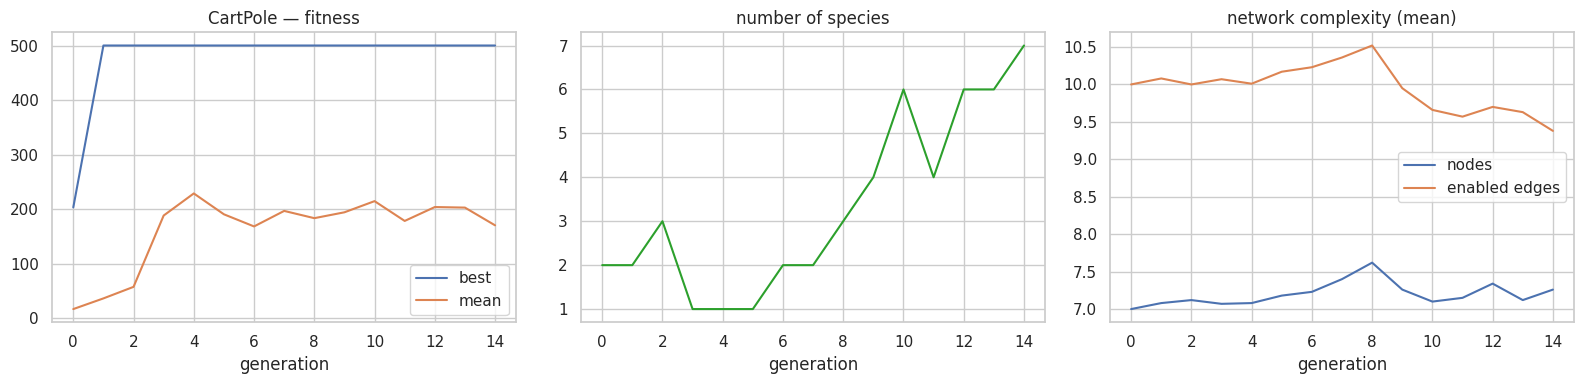

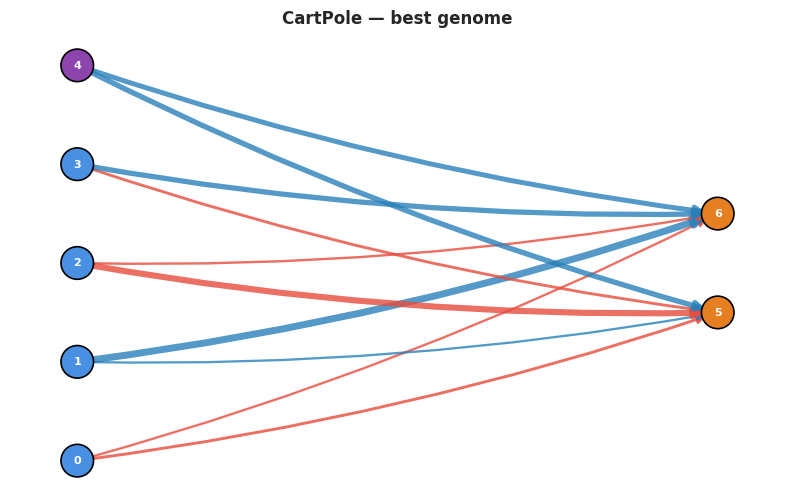

In [10]:
make_cartpole = lambda: gym.make("CartPole-v1")

best_cartpole, report_cartpole = train_NEAT(
    gym_env_func=make_cartpole, action_mapper=argmax_action_mapper,
    max_steps=500, n_runs=2, max_iterations=15, population_size=100,
    compatibility_threshold=3.0, n_target_species=6, seed=0,
    final_selection_episodes=20)

scores = evaluate_heldout(best_cartpole, 'CartPole-v1', argmax_action_mapper, max_steps=500)
print(f"\nCartPole held-out over 100 unseen episodes: {scores.mean():.1f} "
      f"(min {scores.min():.0f} / max {scores.max():.0f} / std {scores.std():.1f})")
print(f"Best genome: {best_cartpole.network.number_of_nodes()} nodes "
      f"({best_cartpole.n_hidden()} hidden), {best_cartpole.n_enabled_edges()} enabled edges")

plot_training(report_cartpole, 'CartPole')
visualize_network(best_cartpole, "CartPole — best genome"); plt.show()

# Benchmark 2 — LunarLander

8 inputs, 4 discrete actions, solved = 200. Rewards start out **negative** (every lander crashes at
first), which is exactly the regime in which the offspring allocation must handle negative fitness
correctly.

Gen [00] best=  -80.14 mean= -545.95 species= 40 threshold=1.800 nodes=13.0 edges=36.0


Gen [01] best=  -81.39 mean= -350.10 species= 25 threshold=1.890 nodes=13.1 edges=36.1


Gen [02] best=  -72.27 mean= -414.73 species= 15 threshold=1.985 nodes=13.1 edges=36.1


Gen [03] best=  -70.27 mean= -228.79 species= 12 threshold=2.084 nodes=13.1 edges=36.2


Gen [04] best=  -81.59 mean= -244.58 species=  7 threshold=2.188 nodes=13.5 edges=36.5


...

Gen [77] best=   93.42 mean= -213.54 species=  9 threshold=1.753 nodes=15.8 edges=40.4


Gen [78] best=  106.24 mean= -219.42 species= 10 threshold=1.666 nodes=16.0 edges=41.0


Gen [79] best=  193.96 mean= -240.10 species= 12 threshold=1.666 nodes=15.9 edges=40.9



re-ranked the 5 best champions over 20 common episodes -> selected mean 178.0



LunarLander held-out over 100 unseen episodes: 172.0 +/- 118.9 (solved >= 200)
Best genome: 13 nodes (0 hidden), 35 enabled edges


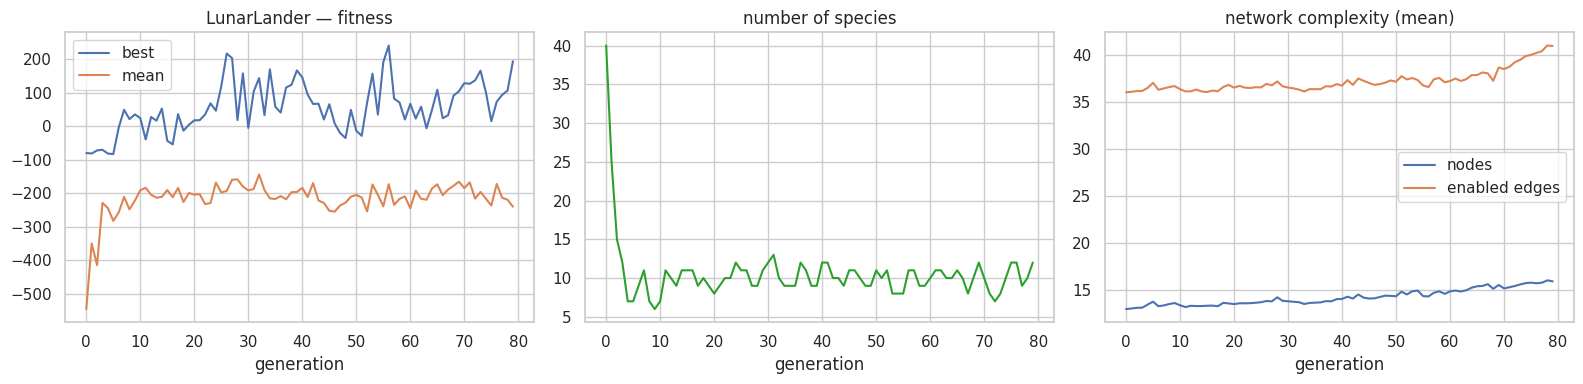

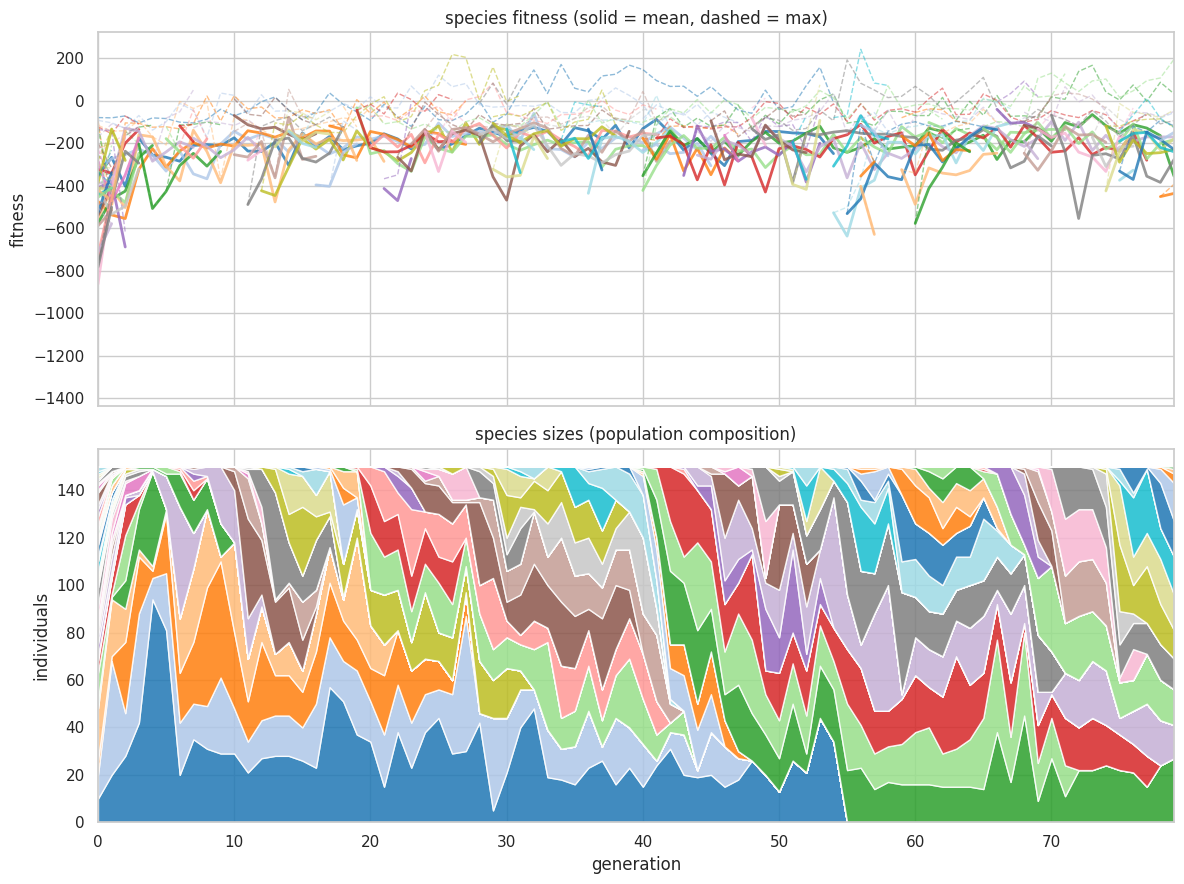

In [11]:
make_lunar = lambda: gym.make('LunarLander-v3')

best_lunar, report_lunar = train_NEAT(
    gym_env_func=make_lunar, action_mapper=argmax_action_mapper,
    max_steps=1000, n_runs=3, max_iterations=80, population_size=150,
    compatibility_threshold=1.8, n_target_species=10, seed=0,
    final_selection_episodes=20)

scores_lunar = evaluate_heldout(best_lunar, 'LunarLander-v3', argmax_action_mapper, max_steps=1000)
print(f"\nLunarLander held-out over 100 unseen episodes: {scores_lunar.mean():.1f} "
      f"+/- {scores_lunar.std():.1f} (solved >= 200)")
print(f"Best genome: {best_lunar.network.number_of_nodes()} nodes "
      f"({best_lunar.n_hidden()} hidden), {best_lunar.n_enabled_edges()} enabled edges")

plot_training(report_lunar, 'LunarLander')
visualize_species_evolution(report_lunar)

### Successful vs. unsuccessful network

The best and the worst genome of the final generation, side by side.

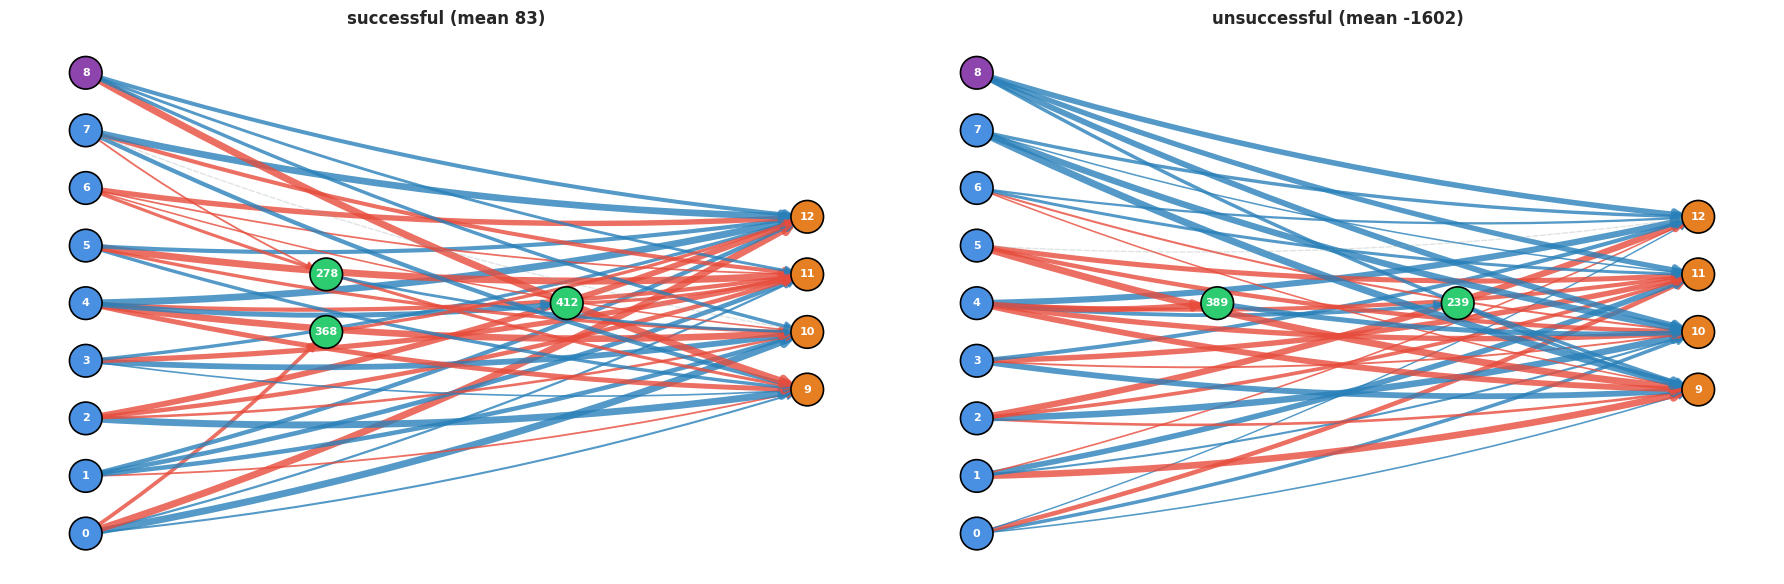

In [12]:
best_g = report_lunar[-1]['best_genome']
worst_g = report_lunar[-1]['worst_genome']
s_best = evaluate_heldout(best_g, 'LunarLander-v3', argmax_action_mapper, n_episodes=20, max_steps=1000)
s_worst = evaluate_heldout(worst_g, 'LunarLander-v3', argmax_action_mapper, n_episodes=20, max_steps=1000)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
visualize_network(best_g, f"successful (mean {s_best.mean():.0f})", ax=axes[0])
visualize_network(worst_g, f"unsuccessful (mean {s_worst.mean():.0f})", ax=axes[1])
plt.tight_layout(); plt.show()

# Benchmark 3 — BipedalWalker

24 inputs, **4 continuous** actions in [-1, 1]. This is why the activation is `tanh` and the action
mapper is the identity — there is no `argmax` here. Solved would be ~300; we report honest progress.

Gen [00] best=  -32.57 mean= -105.25 species=  8 threshold=2.100 nodes=29.0 edges=100.0


Gen [01] best=  -27.92 mean= -104.99 species= 11 threshold=1.995 nodes=29.1 edges=100.1


Gen [02] best=  -41.48 mean= -104.02 species=  8 threshold=2.095 nodes=29.1 edges=100.1


Gen [03] best=  -34.62 mean= -103.28 species=  6 threshold=1.990 nodes=29.2 edges=100.0


Gen [04] best=  -35.25 mean= -103.81 species=  6 threshold=1.891 nodes=29.2 edges=100.1


...

Gen [37] best=  -30.96 mean=  -96.11 species= 10 threshold=1.502 nodes=30.6 edges=102.4


Gen [38] best=  -30.27 mean=  -96.52 species=  9 threshold=1.502 nodes=30.6 edges=102.2


Gen [39] best=   -6.27 mean=  -99.86 species=  9 threshold=1.427 nodes=30.6 edges=102.2



re-ranked the 5 best champions over 10 common episodes -> selected mean 11.2



BipedalWalker held-out over 20 unseen episodes: 2.2 +/- 28.8 (solved ~300)
Best genome: 29 nodes (0 hidden), 100 enabled edges


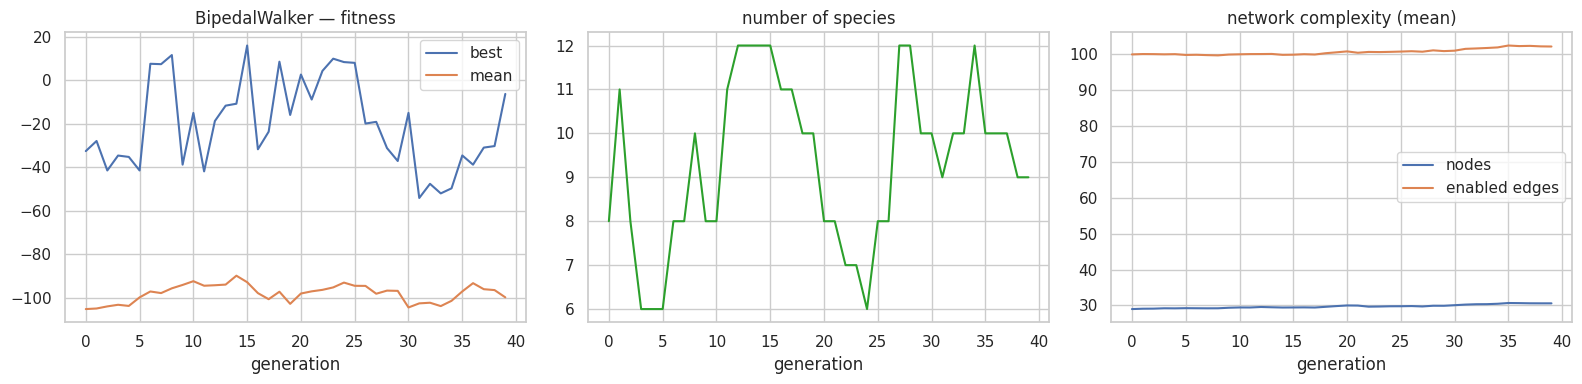

In [13]:
make_bipedal = lambda: gym.make('BipedalWalker-v3')

best_bipedal, report_bipedal = train_NEAT(
    gym_env_func=make_bipedal, action_mapper=continuous_action_mapper,
    max_steps=800, n_runs=2, max_iterations=40, population_size=100,
    compatibility_threshold=2.1, n_target_species=10, seed=0,
    final_selection_episodes=10)

scores_bw = evaluate_heldout(best_bipedal, 'BipedalWalker-v3', continuous_action_mapper,
                             n_episodes=20, max_steps=800)
print(f"\nBipedalWalker held-out over 20 unseen episodes: {scores_bw.mean():.1f} "
      f"+/- {scores_bw.std():.1f} (solved ~300)")
print(f"Best genome: {best_bipedal.network.number_of_nodes()} nodes "
      f"({best_bipedal.n_hidden()} hidden), {best_bipedal.n_enabled_edges()} enabled edges")

plot_training(report_bipedal, 'BipedalWalker')

# Analysis 1 — How does speciation affect performance?

`use_speciation=False` puts the whole population into a single species: fitness sharing and the protected
niches disappear, and every genome competes directly against every other. Identical configuration,
identical seeds, one single difference. LunarLander, 25 generations, population 60, averaged over 3 seeds.

**The measurement does not confirm the textbook expectation, and we report it as measured.** On this budget
the un-speciated population reaches the *higher* best fitness (mean of the last 5 generations: 48.7 against
-42.0). What speciation does deliver is **stability**: the run-to-run standard deviation falls from 73.6 to
27.1, a factor of ~2.7.

The interpretation: fitness sharing spends a large part of the budget keeping weak niches alive, which costs
raw progress over a short horizon. Its protection of new topologies can only pay off once structural
innovation is the thing that limits performance — and with 25 generations, 60 individuals and a task that
turns out to need no hidden structure at all (Analysis 3), that point is never reached. A single greedy
species simply tunes weights faster.

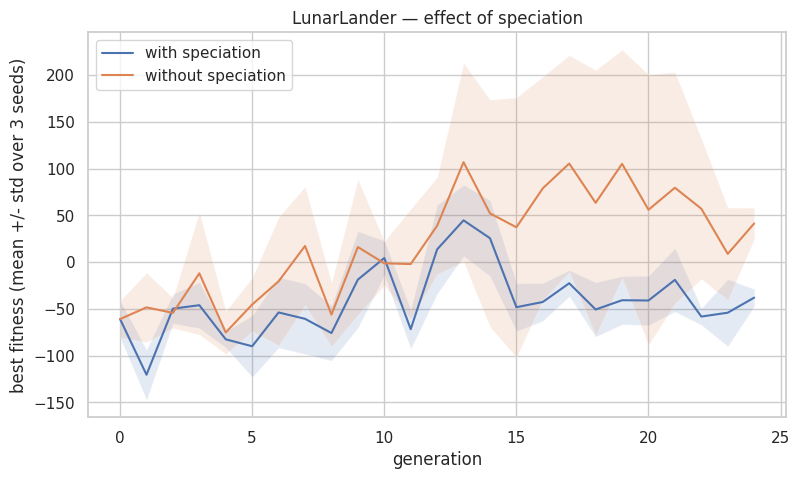

final generation   : with  -37.91 +/-  9.19   without   41.43 +/- 16.69
mean of last 5 gens: with  -41.99            without   48.65
mean std across all gens (run-to-run spread): with 27.13   without 73.55


In [14]:
SEEDS = (0, 1, 2)

def best_curves(use_speciation, **kw):
    """Best-fitness curve per seed -> mean and std across seeds."""
    curves = [[r['best_fitness'] for r in
               train_NEAT(use_speciation=use_speciation, seed=s, verbose=False, **kw)[1]]
              for s in SEEDS]
    curves = np.array(curves)
    return curves.mean(axis=0), curves.std(axis=0)


base = dict(gym_env_func=make_lunar, action_mapper=argmax_action_mapper, max_steps=1000,
            n_runs=2, max_iterations=25, population_size=60, compatibility_threshold=1.8,
            n_target_species=8)

mean_spec, std_spec = best_curves(True, **base)
mean_flat, std_flat = best_curves(False, **base)

gens = np.arange(len(mean_spec))
plt.figure(figsize=(9, 5))
for mean, std, label in [(mean_spec, std_spec, 'with speciation'),
                         (mean_flat, std_flat, 'without speciation')]:
    plt.plot(gens, mean, label=label)
    plt.fill_between(gens, mean - std, mean + std, alpha=0.15)
plt.xlabel('generation'); plt.ylabel(f'best fitness (mean +/- std over {len(SEEDS)} seeds)')
plt.title('LunarLander — effect of speciation'); plt.legend(); plt.show()

print(f"final generation   : with {mean_spec[-1]:7.2f} +/- {std_spec[-1]:5.2f}   "
      f"without {mean_flat[-1]:7.2f} +/- {std_flat[-1]:5.2f}")
print(f"mean of last 5 gens: with {mean_spec[-5:].mean():7.2f}            "
      f"without {mean_flat[-5:].mean():7.2f}")
print(f"mean std across all gens (run-to-run spread): with {std_spec.mean():.2f}   "
      f"without {std_flat.mean():.2f}")

# Analysis 2 — Which mutation rates give stable results?

Sweep of `mut_p_add_node`, 3 seeds per rate, everything else held fixed. The score is the best fitness
averaged over the last 3 generations, because a single generation's best is a very noisy estimate.

`mut_p_add_node = 0` is clearly the worst setting (-34.6): with no structural mutation the population can
only re-tune the weights of its initial topology. Rates from 0.02 to 0.15 are **statistically
indistinguishable** — their error bars overlap heavily (0.05: 28.1 +/- 28.1 against 0.15: 8.6 +/- 24.6) —
and 0.3 trends back down as the networks bloat with untuned weights. 0.05 has the best mean and is the
default used for the benchmarks above.

The honest reading: whether structural mutation happens *at all* clearly matters; its exact rate, within
an order of magnitude, does not.

mut_p_add_node=0.0   -> best fitness   -34.63 (+/- 18.33)


mut_p_add_node=0.02  -> best fitness    11.34 (+/- 72.96)


mut_p_add_node=0.05  -> best fitness    28.05 (+/- 28.14)


mut_p_add_node=0.15  -> best fitness     8.63 (+/- 24.62)


mut_p_add_node=0.3   -> best fitness    -0.48 (+/- 29.43)


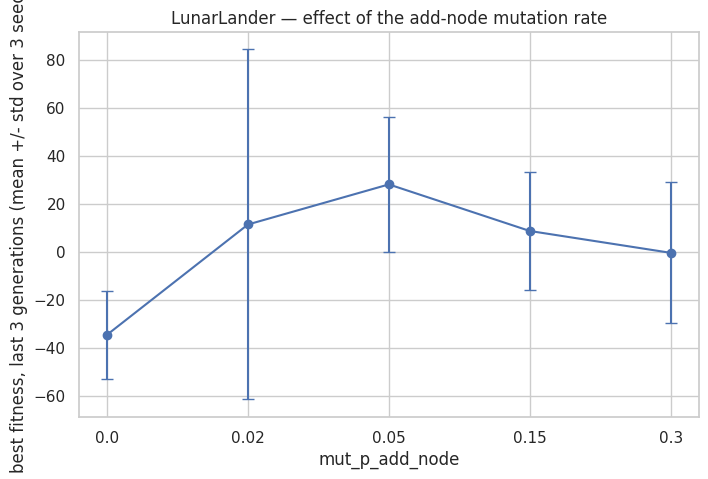

In [15]:
rates = [0.0, 0.02, 0.05, 0.15, 0.3]
SEEDS = (0, 1, 2)
means, stds = [], []

for rate in rates:
    finals = []
    for s in SEEDS:
        _, rep = train_NEAT(
            gym_env_func=make_lunar, action_mapper=argmax_action_mapper, max_steps=1000,
            n_runs=2, max_iterations=15, population_size=60, compatibility_threshold=1.8,
            n_target_species=8, seed=s, verbose=False,
            genome_config=GenomeConfig(mut_p_add_node=rate))     # only this one value changes
        # average the last 3 generations: a single generation's best is a very noisy estimate
        finals.append(float(np.mean([r['best_fitness'] for r in rep[-3:]])))
    means.append(np.mean(finals)); stds.append(np.std(finals))
    print(f"mut_p_add_node={rate:<5} -> best fitness {np.mean(finals):8.2f} (+/- {np.std(finals):.2f})")

plt.figure(figsize=(8, 5))
plt.errorbar([str(r) for r in rates], means, yerr=stds, marker='o', capsize=4)
plt.xlabel('mut_p_add_node')
plt.ylabel(f'best fitness, last 3 generations (mean +/- std over {len(SEEDS)} seeds)')
plt.title('LunarLander — effect of the add-node mutation rate'); plt.show()

# Analysis 3 — How does network complexity evolve?

NEAT starts minimal (no hidden nodes, inputs and bias wired straight to the outputs) and should only grow
when growth pays for itself. The curves come from the three benchmark runs above — nothing is retrained.

Two things happen at once and are worth separating:

- the **population mean** drifts upward (LunarLander: 13.0 -> 15.9 nodes over 80 generations), because
  add-node mutations keep accumulating;
- yet the **champion of every one of the three benchmarks ends with zero hidden nodes** — precisely the
  topology it started from.

The added structure never wins. All three tasks are solved, as far as they are solved here, by an
essentially linear policy over the observations, and NEAT refuses to pay for structure it cannot exploit.
That is the complexification principle doing its job — just with a less flattering answer than the usual
illustration: on these benchmarks there is nothing for the hidden layer to do.

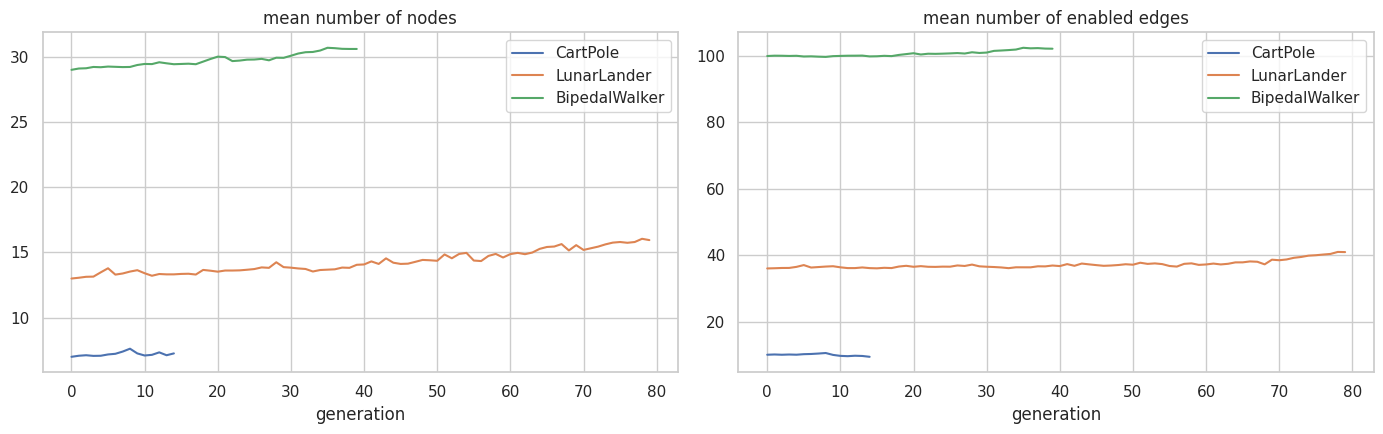

CartPole        minimal start:  7 nodes /  10 edges -> best genome:  7 nodes /  10 edges  (0 hidden nodes evolved)
LunarLander     minimal start: 13 nodes /  36 edges -> best genome: 13 nodes /  35 edges  (0 hidden nodes evolved)
BipedalWalker   minimal start: 29 nodes / 100 edges -> best genome: 29 nodes / 100 edges  (0 hidden nodes evolved)


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for rep, name in [(report_cartpole, 'CartPole'), (report_lunar, 'LunarLander'),
                  (report_bipedal, 'BipedalWalker')]:
    ax[0].plot([r['mean_nodes'] for r in rep], label=name)
    ax[1].plot([r['mean_edges'] for r in rep], label=name)
ax[0].set_title('mean number of nodes'); ax[0].set_xlabel('generation'); ax[0].legend()
ax[1].set_title('mean number of enabled edges'); ax[1].set_xlabel('generation'); ax[1].legend()
plt.tight_layout(); plt.show()

# minimal start = inputs + bias + outputs, fully connected
for model, name, n_in, n_out in [(best_cartpole, 'CartPole', 4, 2),
                                 (best_lunar, 'LunarLander', 8, 4),
                                 (best_bipedal, 'BipedalWalker', 24, 4)]:
    print(f"{name:15s} minimal start: {n_in + 1 + n_out:2d} nodes / {(n_in + 1) * n_out:3d} edges "
          f"-> best genome: {model.network.number_of_nodes():2d} nodes / "
          f"{model.n_enabled_edges():3d} edges  ({model.n_hidden()} hidden nodes evolved)")

# Genetic distance between species

Distance matrix over the species representatives of the final LunarLander generation. The diagonal is 0
by definition; bright off-diagonal cells mean two species really are genetically far apart — evidence
that speciation formed genuinely separate niches rather than arbitrary labels.

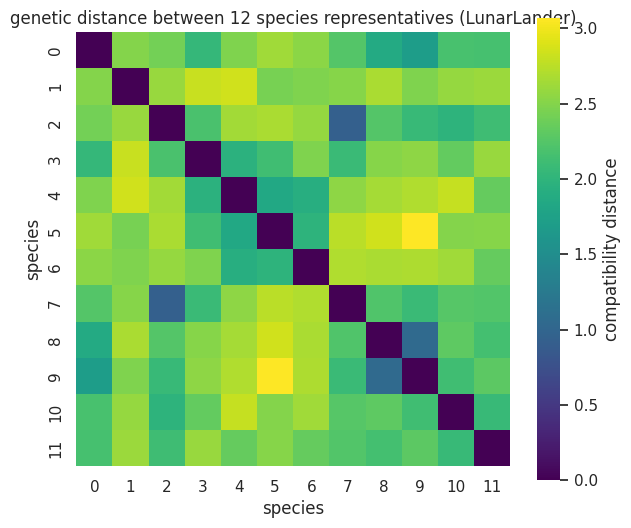

In [17]:
reps = report_lunar[-1]['representatives']
D = np.array([[a.distance(b) for b in reps] for a in reps])

plt.figure(figsize=(7, 6))
sns.heatmap(D, cmap='viridis', square=True, cbar_kws={'label': 'compatibility distance'})
plt.title(f'genetic distance between {len(reps)} species representatives (LunarLander)')
plt.xlabel('species'); plt.ylabel('species'); plt.show()

# Conclusion

All scores below are **held-out**: fixed seeds evolution never saw, and the champion is first re-ranked
against the other top genomes over a common set of episodes. They are therefore not the optimistically
biased fitness reached during evolution.

| Benchmark | held-out score | solved at |
|---|---|---|
| CartPole | **500.0** +/- 0.0 (100 episodes) | 500 |
| LunarLander | **172.0** +/- 118.9 (100 episodes) | 200 |
| BipedalWalker | **2.2** +/- 28.8 (20 episodes) | ~300 |

- **CartPole** is solved perfectly, straight from the minimal topology — the sanity check passes.
- **LunarLander** reaches a usable policy at 172, close to but short of the 200 threshold. The large
  standard deviation is the informative part: the lander is competent in most episodes and still crashes in
  a minority of them.
- **BipedalWalker** is not solved. It escapes the -100 "falls over immediately" regime and then stalls near
  0 reward — it learns to stay upright without learning to walk. Here the compute budget (40 generations,
  population 100) is the binding constraint.
- **Speciation** did not improve the score on our budget. It cut the run-to-run spread by a factor of ~2.7
  while lowering the mean (Analysis 1); we report that as measured rather than as expected.
- **Mutation rate**: the presence of structural mutation is what matters — 0.0 is clearly the worst — while
  any rate between 0.02 and 0.15 lies within the noise (Analysis 2).
- **Complexity**: the population complexifies, but every champion stays at zero hidden nodes (Analysis 3).
  On these three tasks NEAT finds no structure worth paying for.

Two design decisions carry most of the result and are easy to overlook. The **bias node**, without which
every activation is pinned to the origin and no neuron can shift its own threshold; and the **re-ranking of
the champion** on a common set of episodes, without which the returned genome is simply the luckiest one of
its generation rather than the best one — on a reward as noisy as LunarLander's, that difference is large.